<a href="https://colab.research.google.com/github/flagg11/text_labaS/blob/laba1/%D0%A1%D0%B5%D0%BC%D0%B8%D0%BD%D0%B0%D1%80_2_%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 1

Цель: освоить основные инструменты для предварительной обработки и первичного анализа текстовых данных

### План

*   Exploratory Data Analysis (EDA) - Первичный/разведочный анализ и очистка данных
*   Предварительная обработка текстовых данных
*   Формирование векторов/массивов признаков (feature vectors) для обучения модели
*   Кодирование категориальных целевых перемменных (Labelling)
*   Построение простейшей нейронной сети для классификации в Tensorflow.Keras
*   Оценка качества обучения  




In [5]:
!pip install tensorflow numpy pandas matplotlib seaborn scikit-learn pymorphy3 nltk


In [6]:
# Импорт необходимых библиотек
# Успешное выполнение этой ячейки кода подтверждает правильную настройку среды разработки

import numpy as np
import pandas as pd
import re
import pymorphy3
import nltk
import matplotlib.pyplot as plt
%matplotlib inline
from tensorflow.keras.preprocessing.text import Tokenizer

nltk.download('punkt_tab')
nltk.download('stopwords')

from tensorflow.keras import utils
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem.snowball import SnowballStemmer
nltk.download('wordnet')



[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# Exploratory Data Analysis (EDA) - Первичный/разведочный анализ и очистка данных

Вы снова будете работать с тем же датасетом из обращений граждан.



In [7]:
df = pd.read_csv('Lesson_1_user_requests.csv')
df.head()

,Unnamed: 0,process_texts,date_add,sphera,raion,statname,vozvrat,date_start,date_end,categoriya,date_reply,aorgan,atag
0,19,Здравствуйте. Подскажите пожалуйста можно ли с...,2006-11-20 00:00:00,Дороги и транспорт,Липецк,Исполнено,NaN,2018-11-19 00:00:00,2018-11-29 00:00:00,Запрос на льготы / субсидии,0000-00-00 00:00:00,Администрация города Липецка (Гл.исполнитель...,"<a class=""DarkRed"" href=""https://artamonovigo..."
1,20,Подскажите пожалуйста имеют ли право не платит...,2006-11-20 00:00:00,ЖКХ,Липецк,Исполнено,NaN,2018-11-19 00:00:00,2018-11-29 00:00:00,Запрос юридической консультации,2011-12-20 00:00:00,Управление ЖКХ Липецкой области (Гл.исполнител...,"<a class=""DarkRed"" href=""https://artamonovigo..."
2,21,""" Спасибо Вам огромное за возобновление строит...",2006-11-20 00:00:00,Строительство,Липецк,Исполнено,NaN,2018-11-08 00:00:00,2019-03-31 00:00:00,Запрос юридической консультации,2019-11-20 00:00:00,Государственная жилищная инспекция (К исполнен...,"<a class=""DarkRed"" href=""https://artamonovigo..."
3,22,Проблема одна и общая стала в городе. Спорт. у...,2006-11-20 00:00:00,Спорт,Липецк,Исполнено,NaN,2018-11-08 00:00:00,2018-11-17 00:00:00,Недовольство общее,0000-00-00 00:00:00,Кокин Егор Иванович (); Управление физической ...,"<a class=""DarkRed"" href=""https://artamonovigo..."
4,23,Некоторое время назад для школьников и студент...,2006-11-20 00:00:00,Дороги и транспорт,Липецк,Исполнено,NaN,2018-11-19 00:00:00,2018-12-05 00:00:00,Запрос на льготы / субсидии,2026-11-20 00:00:00,Управление социальной защиты населения Липецко...,"<a class=""DarkRed"" href=""https://artamonovigo..."


In [8]:
# Нас интересуют только значения "process_texts" - тексты самих обращений, "sphera" - тема, к которой относится письмо, и "categoriya" - категория обращений
df_text = df.copy(deep=True)
df_text = df_text[['process_texts','sphera', 'categoriya']]
df_text.head(10)

,process_texts,sphera,categoriya
0,Здравствуйте. Подскажите пожалуйста можно ли с...,Дороги и транспорт,Запрос на льготы / субсидии
1,Подскажите пожалуйста имеют ли право не платит...,ЖКХ,Запрос юридической консультации
2,""" Спасибо Вам огромное за возобновление строит...",Строительство,Запрос юридической консультации
3,Проблема одна и общая стала в городе. Спорт. у...,Спорт,Недовольство общее
4,Некоторое время назад для школьников и студент...,Дороги и транспорт,Запрос на льготы / субсидии
5,"Доброго времени суток! Надеюсь, мое сообщение ...",Дороги и транспорт,Недовольство общее
6,хочу предложить вот что у нас в городе потихон...,Дороги и транспорт,Потребность в благоустройстве
7,"Добрый вечер. Хотелось бы, чтобы обратили вним...",Дороги и транспорт,Потребность в ремонте дорог
8,"Здравствуйте, больше 9 месяцев я и жильцы микр...",Благо­­устрой­­ство,Недовольство общее
9,На улице Кирова (это центр города!!!!) отсутст...,Дороги и транспорт,Потребность в ремонте дорог


In [9]:
# Ещё один удобный способ посмотреть на количество ненулевых и уникальных значений в таблице по каждой переменной (как и другие статистики по численным ппеременным) - функция describe()
df_text.describe(include='all')

,process_texts,sphera,categoriya
count,10194,8369,8338
unique,10005,21,19
top,""" Доброго времени суток!!! Проблема нашего дом...",ЖКХ,Недовольство общее
freq,7,2101,2449


# Задание 1 (Удаление пустых строк)
Найдите и удалите из таблицы все строки с пропущенными значениями текстов обращений и вашей целевой переменной (в зависимости от варианта sphera или categoriya)

In [10]:
#### ВСТАВЬТЕ КОД СЮДА
df_text = df_text.dropna(subset=['process_texts', 'categoriya'])
print("Всего строк в таблице без пропущенных значений: ", df_text.shape[0])
####

print("Всего строк в таблице без пропущенных значений: ", df_text.shape[0])

Всего строк в таблице без пропущенных значений:  8335
Всего строк в таблице без пропущенных значений:  8335


# Задание 2 (Удаление повторяющихся обращений)
Найдите и удалите из таблицы все повторяющиеся обращения (полные дубликаты).

In [11]:
#### ВСТАВЬТЕ КОД СЮДА
df_text = df_text.drop_duplicates()
####

print(f'Таблца без повторяющихся обращений содержит {df_text.shape[0]} строк.')

Таблца без повторяющихся обращений содержит 8208 строк.


Теперь посмотрим на распределение целевых переменных по классам

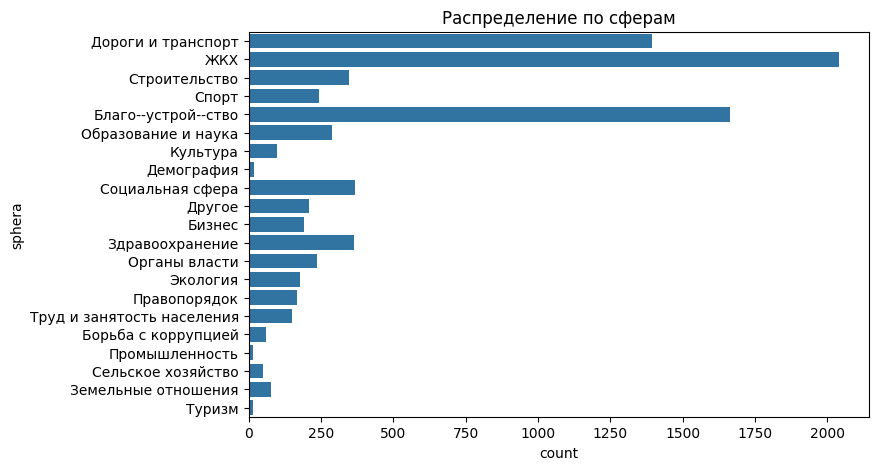

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(y='sphera', data=df_text)
plt.title('Распределение по сферам')
plt.show()

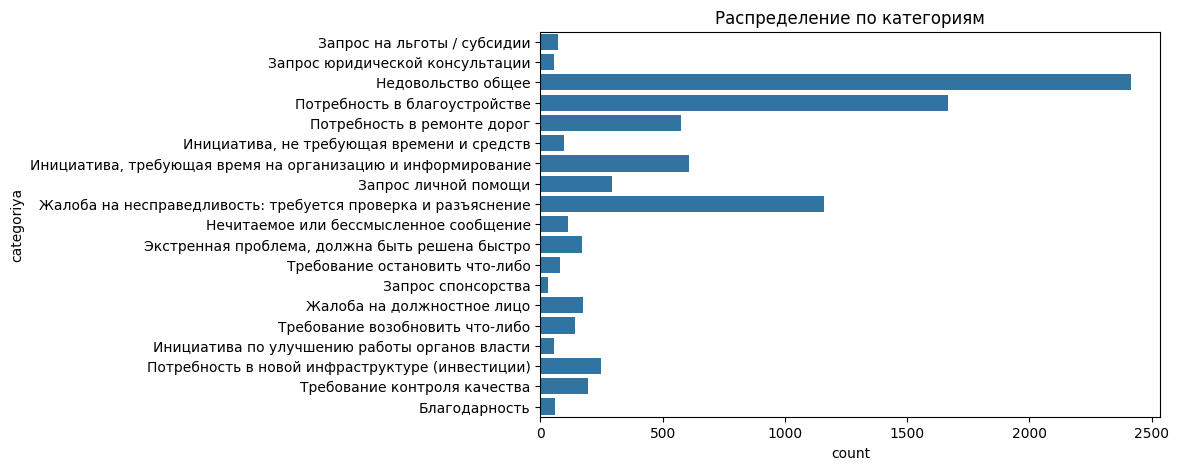

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(y='categoriya', data=df_text)
plt.title('Распределение по категориям')
plt.show()

Мы видим явную несбалансированность классов для обеих переменных. Скорее всего, при использовании подобного датасета наша простая модель будет склоняться к предсказанию чаще встречающихся классов, то есть будет предвзята (biased).


# Задание 2* (Удаление классов)
Если у вас в варианте указана дополнительная работа над целевой переменной, удалите из таблицы соответствующие строки.

In [14]:
#### ВСТАВЬТЕ КОД СЮДА
...
####

In [15]:
print(f'Таблца теперь содержит {df_text.shape[0]} строк.')

Таблца теперь содержит 8208 строк.


# Предварительная обработка текстовых данных

# Задание 3 (Предварительная обработка)


*   Удалите из текстов обращений лишние символы, оставьте только слова (буквы)
*   Приведите слова к нижнеу регистру
*   Удалите русские стоп-слова из списка nltk.corpus.stopwords.words("russian")
*   Проведите нормализацию слов. В зависимости от варианта, стемминг (используйте nltk.stem.snowball.SnowballStemmer()) или лемматизацию (используйте pymorphy3.MorphAnalyzer())


In [16]:
from nltk.corpus import stopwords
import re
import pymorphy3

morph = pymorphy3.MorphAnalyzer()
stop_words = set(stopwords.words("russian"))

def preprocess(text):
    # Удаляем всё, кроме букв
    text = re.sub(r'[^а-яА-ЯёЁ]', ' ', text)
    # Приводим к нижнему регистру
    text = text.lower()
    # Токенизация
    words = text.split()
    # Удаляем стоп-слова и лемматизируем
    tokens = [morph.parse(word)[0].normal_form for word in words if word not in stop_words]
    return " ".join(tokens)

In [17]:
df_text['clean_text'] = df_text['process_texts'].apply(preprocess)

In [18]:
df_text.head()

,process_texts,sphera,categoriya,clean_text
0,Здравствуйте. Подскажите пожалуйста можно ли с...,Дороги и транспорт,Запрос на льготы / субсидии,здравствуйте подсказать пожалуйста сделать про...
1,Подскажите пожалуйста имеют ли право не платит...,ЖКХ,Запрос юридической консультации,подсказать пожалуйста иметь право платить какп...
2,""" Спасибо Вам огромное за возобновление строит...",Строительство,Запрос юридической консультации,спасибо огромный возобновление строительство м...
3,Проблема одна и общая стала в городе. Спорт. у...,Спорт,Недовольство общее,проблема один общий стать город спорт хоккейны...
4,Некоторое время назад для школьников и студент...,Дороги и транспорт,Запрос на льготы / субсидии,некоторый время назад школьник студент проезд ...


Вы можете посмотреть на распределение длин обращений в словах, используя код ниже.

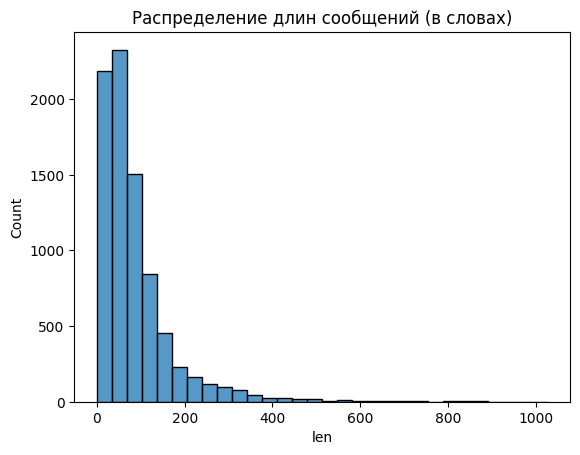

In [19]:
# Длина сообщений
df_text['len'] = df_text['clean_text'].apply(lambda x: len(x.split()))
sns.histplot(df_text['len'], bins=30)
plt.title('Распределение длин сообщений (в словах)')
plt.show()

# Формирование векторов/массивов признаков (feature vectors) для обучения модели

# Задание 4 (Токенизация и векторизация текстов)

Используйте методы fit_on_texts() и texts_to_matrix() класса Tokenizer для формирования словаря и векторизации текстов с учётом вашего варианта! (num_words и mode в texts_to_matrix())




In [20]:
texts = df_text['clean_text'].values #Извлекаем все тексты обращений

In [21]:
#### ВСТАВЬТЕ КОД СЮДА
texts = df_text['clean_text'].values

maxWordsCount = 4000
tokenizer = Tokenizer(num_words=maxWordsCount, filters=' ')
tokenizer.fit_on_texts(texts)
xAll = tokenizer.texts_to_matrix(texts, mode='tfidf')

####
print(xAll.shape)  # Посмотрим на размерность матрицы
print(xAll[0, :20])# И отдельно на фрагмент начала первого вектора

list_columns = list(tokenizer.word_index.keys())[:maxWordsCount]

(8208, 4000)
[0.         0.         0.         0.         0.         0.
 1.5091195  0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         1.74206528
 0.         0.        ]


# Задание 5 (Кодирование категориальных целевых перемменных - Labelling)

Вставьте пропущенные строки кода (по вариантам)

In [22]:
#### ВСТАВЬТЕ КОД СЮДА
# ...
classes = df_text['categoriya'].values
nClasses = len(set(classes))
####

#Преобразовываем категории в вектор целевой переменной
encoder = LabelEncoder() # Вызываем метод кодирования категориальных переменных из библиотеки sklearn
encoder.fit(classes) # Подгружаем в него категории
classesEncoded = encoder.transform(classes) # Кодируем категории
print("Все классы: ", encoder.classes_)
print("Длина вектора: ", classesEncoded.shape)
print("Начало вектора: ",classesEncoded[:20])

Все классы:  ['Благодарность' 'Жалоба на должностное лицо'
 'Жалоба на несправедливость: требуется проверка и разъяснение'
 'Запрос личной помощи' 'Запрос на льготы / субсидии' 'Запрос спонсорства'
 'Запрос юридической консультации'
 'Инициатива по улучшению работы органов власти'
 'Инициатива, не требующая времени и средств'
 'Инициатива, требующая время на организацию и информирование'
 'Недовольство общее' 'Нечитаемое или бессмысленное сообщение'
 'Потребность в благоустройстве'
 'Потребность в новой инфраструктуре (инвестиции)'
 'Потребность в ремонте дорог' 'Требование возобновить что-либо'
 'Требование контроля качества' 'Требование остановить что-либо'
 'Экстренная проблема, должна быть решена быстро']
Длина вектора:  (8208,)
Начало вектора:  [ 4  6  6 10  4 10 12 14 10 14 12 12  8 12 12 10 12  9  8 14]


In [23]:
yAll = utils.to_categorical(classesEncoded, nClasses) # И выводим каждый лейбл в виде вектора длиной 22,
# с 1кой в позиции соответствующего класса и нулями (one-hot encoding)
print("Форма полученной матрицы: ", yAll.shape)
print("Отдельная вектор-строка матрицы, указывающая на класс " + encoder.classes_[classesEncoded[0]] + ": ", yAll[0]) # И отдельный вектор - строку матрицы, указывающую на класс 'Дороги и транспорт'

Форма полученной матрицы:  (8208, 19)
Отдельная вектор-строка матрицы, указывающая на класс Запрос на льготы / субсидии:  [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


# Задание 6 (Разбиение н тренировочную и тестовую выборки)
Используйте метод train_test_split(), проверьте, есть ли дополнительные требования в варианте

In [24]:
#### ВСТАВЬТЕ КОД СЮДА
from sklearn.model_selection import train_test_split
from tensorflow.keras import utils

yAll = utils.to_categorical(classesEncoded, nClasses)

xTrain, xVal, yTrain, yVal = train_test_split(
    xAll, yAll, test_size=0.2, random_state=42
)

####

## Построение простейшей нейронной сети для классификации в Tensorflow.Keras

In [25]:
#Создаём полносвязную сеть
model01 = Sequential()
#Входной полносвязный слой
model01.add(Dense(100, input_dim=maxWordsCount,
                  activation="relu"))
#Слой регуляризации Dropout
model01.add(Dropout(0.4))
#Второй полносвязный слой
model01.add(Dense(100, activation='relu'))
#Слой регуляризации Dropout
model01.add(Dropout(0.4))
#Третий полносвязный слой
model01.add(Dense(100, activation='relu'))
#Слой регуляризации Dropout
model01.add(Dropout(0.4))
#Выходной полносвязный слой
model01.add(Dense(nClasses, activation='softmax'))


model01.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#Обучаем сеть на выборке
history = model01.fit(xTrain,
                    yTrain,
                    epochs=20,
                    batch_size=128,
                    validation_data=(xVal, yVal))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.2006 - loss: 2.7182 - val_accuracy: 0.3691 - val_loss: 2.0922
Epoch 2/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3453 - loss: 2.0696 - val_accuracy: 0.3995 - val_loss: 1.9235
Epoch 3/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4107 - loss: 1.8556 - val_accuracy: 0.4689 - val_loss: 1.8054
Epoch 4/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4978 - loss: 1.6165 - val_accuracy: 0.4720 - val_loss: 1.7701
Epoch 5/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5628 - loss: 1.4009 - val_accuracy: 0.4744 - val_loss: 1.7928
Epoch 6/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6299 - loss: 1.2167 - val_accuracy: 0.4683 - val_loss: 1.8791
Epoch 7/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6612 - loss: 1.0761 - val_accuracy: 0.4689 - val_loss: 1.9651
Epoch 8/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7094 - loss: 0.9367 - val_accuracy: 0.4769 - val_loss

## Оценка качества обучения  

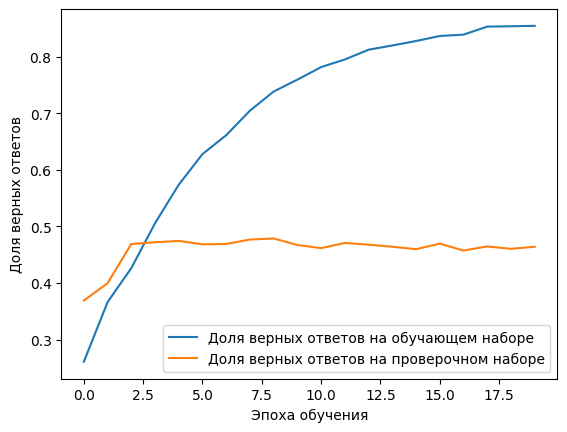

In [26]:
plt.plot(history.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

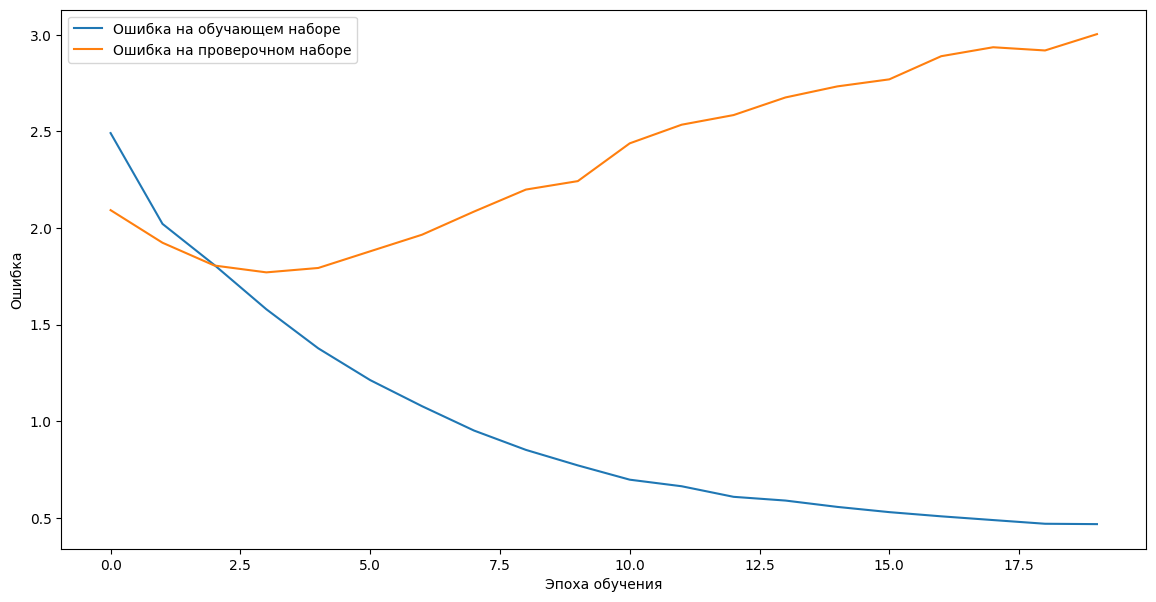

In [27]:
plt.figure(figsize=(14,7))
plt.plot(history.history['loss'],
         label='Ошибка на обучающем наборе')
plt.plot(history.history['val_loss'],
         label='Ошибка на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Ошибка')
plt.legend()
plt.show()

In [28]:
model01.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │       400,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 19)             │         1,919 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,266,659 (4.83 MB)

 Trainable params: 422,219 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 844,440 (3.22 MB)

# Формирование прогноза (Inference)

In [29]:
currPred = model01.predict(xTrain[[11]])
#Определяем номер распознанного класса для каждохо блока слов
currOut = np.argmax(currPred, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step


In [30]:
currOut

array([2])

In [31]:
encoder.inverse_transform(currOut)

array(['Жалоба на несправедливость: требуется проверка и разъяснение'],
      dtype=object)

In [32]:
label = np.argmax(yTrain[11], axis=0)

label

np.int64(2)

In [33]:
yTrain[11]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0.])

In [34]:
encoder.inverse_transform([label])

array(['Жалоба на несправедливость: требуется проверка и разъяснение'],
      dtype=object)

In [35]:
df_1 = pd.DataFrame([xTrain[11]]) #берем матричный вид обращения
df_1.columns = list_columns
df_1[df_1>0].dropna(axis = 1).columns

Index(['год', 'это', 'ребёнок', 'г', 'просить', 'дорога', 'очень', 'ул',
       'администрация', 'свой', 'вода', 'квартира', 'данный', 'место', 'такой',
       'участок', 'решение', 'должный', 'спасибо', 'сказать', 'деньга',
       'возможность', 'управление', 'сторона', 'хотеться', 'рубль', 'огромный',
       'уважаемый', 'сотрудник', 'последний', 'руб', 'елецкий', 'население',
       'основание', 'квадра', 'ст', 'октябрь', 'канализация', 'депутат',
       'попасть', 'пользоваться', 'выше', 'создание', 'московский', 'иной',
       'учитель', 'торговый', 'запретить', 'отказаться', 'капремонт',
       'оформление', 'незаконно', 'госжилинспекция', 'терапевт', 'твориться',
       'любитель', 'ночной'],
      dtype='object')